## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
import seaborn as sns
# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [2]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function

OBJECT_NAME = "LAMP_NE"
EXPOSURE = 10000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name, exp_time=200):
    bias_folder = f"{object_name}/BIAS_{exp_time}"
    bias_files = sorted(os.listdir(bias_folder))
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)), dtype=np.float32)

    for i, bias in tqdm(enumerate(bias_files)): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data.astype(np.float32)

    master_bias = np.median(biases, axis=2)
    return master_bias

In [4]:
MASTER_BIAS = master_bias(OBJECT_NAME)

0it [00:00, ?it/s]

50it [00:01, 27.09it/s]


### Master bias visualisation

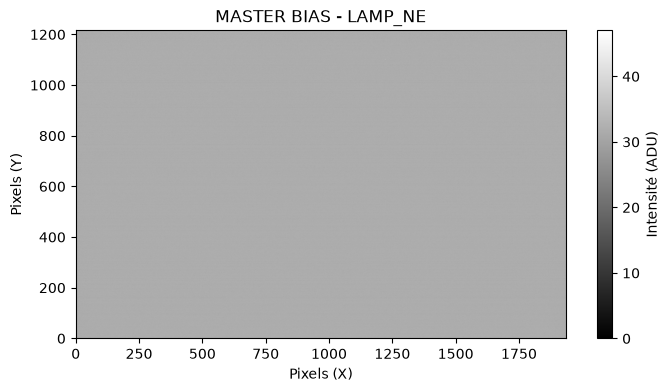

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER BIAS - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **3. Creating the master dark**

We will also remove the master bias from each of them, as to obtain as thermically pure master dark

### Function

s important pour la suite (La soustraction sur tes "Lights")

Puisque ton `master_dark` est maintenant "pur" (sans le bruit de lecture), l'équation de prétraitement pour tes images d'objets (*Light frames*) change.

Au lieu de faire simplement `Light - Master_Dark`, tu devras faire :


$$\text{Image Corrigée} = \text{Light} - \text{Master Bias} - \text{Master Dark}$$

Cette méthode est la plus rigoureuse car elle te permettra plus tard (si tu le souhaites) de "scaler" ton dark. Par exemple, si tu as un Master Dark de 60s mais une image d'objet de 30s, tu pourras faire : `Light - Master_Bias - (Master_Dark * 0.5)`. C'est ultra pratique en astronomie professionnelle ou pour de la recherche d'exoplanètes où les temps de pose varient !

In [6]:
def master_dark(object_name,exp_time, master_bias):
    dark_folder = f"TRUE_DARK_{exp_time}_1/DARK_{exp_time}"
    dark_files = sorted(os.listdir(dark_folder))
    darks = np.zeros((MAX_H,MAX_W,len(dark_files)), dtype=np.float32)

    for i, dark in tqdm(enumerate(dark_files)): # loop for each bias in the bias folder
        with fits.open(f"{dark_folder}/{dark}") as hdul: # open fits file
            darks[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    master_dark = np.median(darks, axis=2)
    return master_dark

In [7]:
MASTER_DARK = master_dark(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

50it [00:02, 21.42it/s]


### Master dark visualization

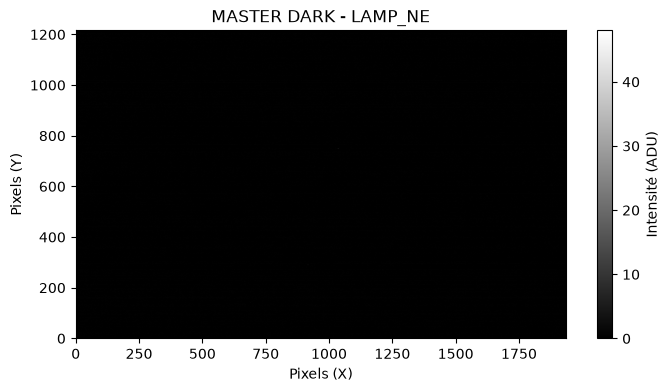

In [8]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_DARK, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER DARK - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **4. Creating the master flat**

Similarly to the master dark, we will substract the bias for each flat frame

### Function

In [9]:
def master_flat(object_name,exp_time, master_bias):
    flat_folder = f"TEST_FLAT/FLAT_{exp_time}"
    flat_files = sorted(os.listdir(flat_folder))
    flats = np.zeros((MAX_H,MAX_W,len(flat_files)), dtype=np.float32)

    for i, flat in tqdm(enumerate(flat_files)): # loop for each bias in the bias folder
        with fits.open(f"{flat_folder}/{flat}") as hdul: # open fits file
            flats[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    raw_master_flat = np.median(flats, axis=2)

    master_flat = raw_master_flat / np.median(raw_master_flat) # correct for the vignetting/dust without changing the actual value of each pixel
    return master_flat

In [10]:
MASTER_FLAT = master_flat(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

20it [00:00, 37.39it/s]


### Master flat visualization

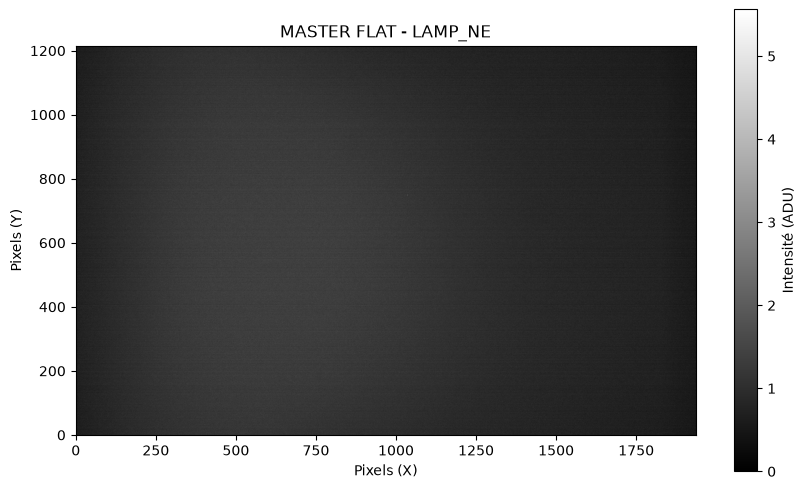

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER FLAT - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

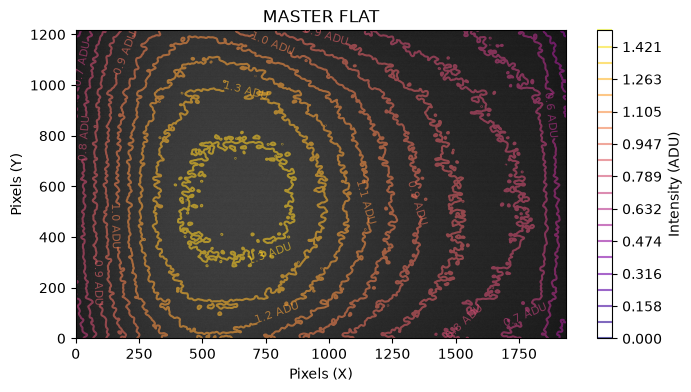

In [12]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

fig, ax = plt.subplots(figsize=(8,4))

# Astuce essentielle : on lisse légèrement l'image (sigma=3 ou 5) 
# UNIQUEMENT pour le calcul des contours, pour éviter le bruit pixel par pixel.
MASTER_FLAT_SMOOTHED = gaussian_filter(MASTER_FLAT, sigma=5)

# On définit des niveaux précis adaptés à ta dynamique (0 à 5 ADU)
# niveaux = [1.0, 2.0, 3.0, 4.0, 5.0]
niveaux = np.linspace(0, 1.5, 20)
im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# Tracé des contours
# cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)
cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)

# Ajout des étiquettes sur les lignes
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f ADU')

ax.set_title(f"MASTER FLAT")# - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(cs, ax=ax, label="Intensity (ADU)")

plt.show()

## **5. Creating the final corrected image**

### Function

In [13]:
def master_science(object_name, exp_time, m_bias, m_dark, m_flat):
    science_folder = f"{object_name}/SCIENCE_{exp_time}"
    science_files = sorted(os.listdir(science_folder))
    sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)

    for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
        with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
            sciences[:,:,i] = hdul[0].data.astype(np.float32) - m_bias.astype(np.float32) - m_dark.astype(np.float32)
            header = hdul[0].header

    master_science_uncorrected = np.median(sciences, axis=2)
    master_science = (np.median(sciences, axis=2)) / m_flat

    return master_science,master_science_uncorrected, header

In [14]:
MASTER_SCIENCE, MASTER_SCIENCE_UNCORR, header = master_science(OBJECT_NAME, EXPOSURE, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

50it [00:01, 28.45it/s]


### Master science visualisation

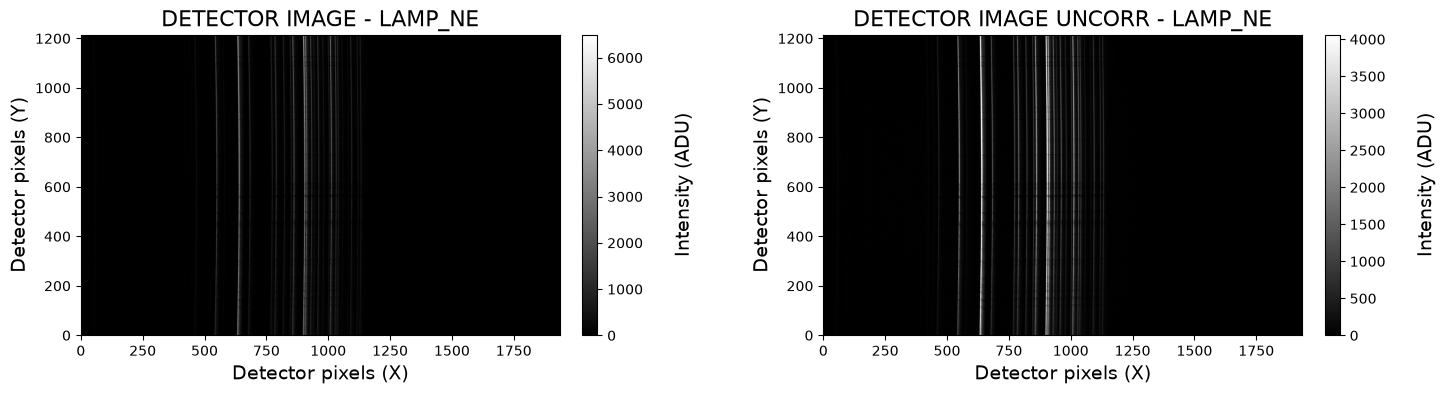

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,4))

im1 = ax1.imshow((MASTER_SCIENCE), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax1.set_title(f"DETECTOR IMAGE - {OBJECT_NAME}", fontsize=16)
ax1.set_xlabel("Detector pixels (X)", fontsize=14)
ax1.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar1 = fig.colorbar(im1, ax=ax1, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar1.set_label('\nIntensity (ADU)', fontsize=14)

im2 = ax2.imshow((MASTER_SCIENCE_UNCORR), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax2.set_title(f"DETECTOR IMAGE UNCORR - {OBJECT_NAME}", fontsize=16)
ax2.set_xlabel("Detector pixels (X)", fontsize=14)
ax2.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar2 = fig.colorbar(im2, ax=ax2, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar2.set_label('\nIntensity (ADU)', fontsize=14)

plt.tight_layout()
plt.show()

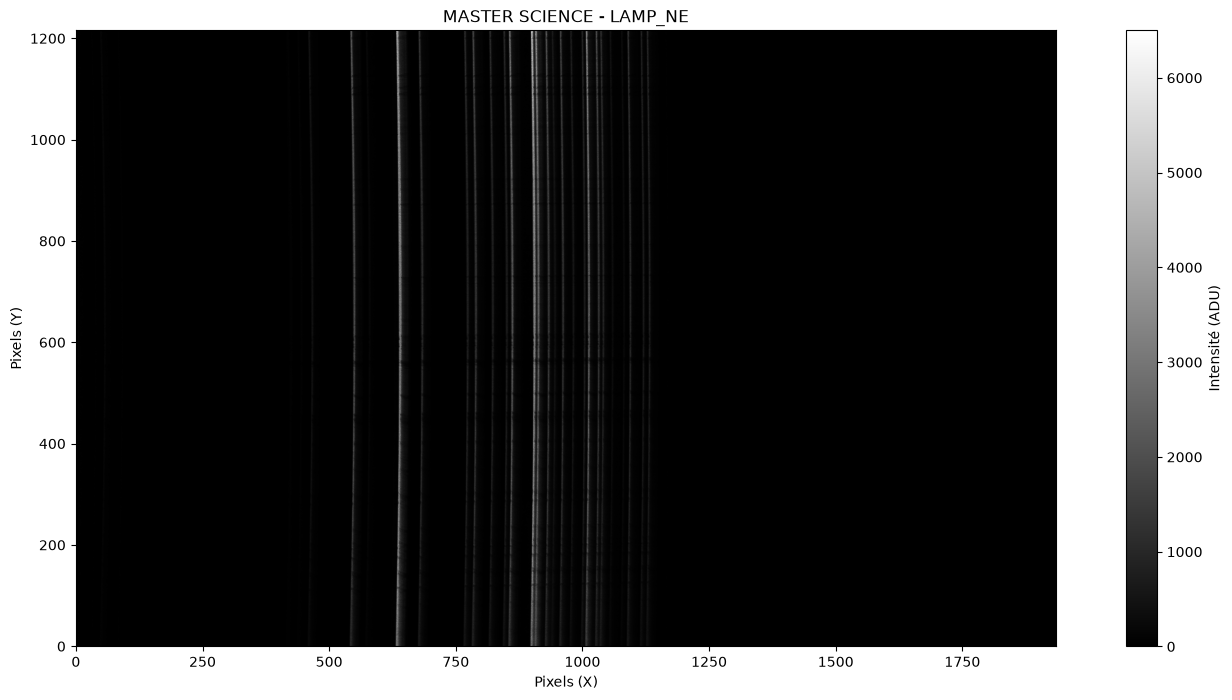

In [16]:
fig, ax = plt.subplots(figsize=(18,8))

im = ax.imshow(MASTER_SCIENCE, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER SCIENCE - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

### <span style="color:red">TODO : Think if I should create a FITS file for the final science calibrated image</span>.

## **6. Spectra visualisation**

### Function

> **The spectra array needs to be reverse, as the +1 order on the detector is red on left and blue on right**

In [17]:
# def spectra_plot(m_science, header, log=False, ylines=[0,607,1215],xmin=0,xmax=1936):
#     fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

#     # m_science = header
#     for line in ylines:
#         if log:
#             ax1.plot(np.log10(m_science[line,:][::-1] + 1 + np.abs(np.min(m_science[line,:][::-1]))),marker='.',ls='',label=f'Line : {line}') # reverse
#             ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
#             # ax1.set_ylim(ymin=1.5)
#         else:
#             ax1.plot(m_science[line,:][::-1],marker='.',ls='',label=f'Line : {line}')
#             ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
#             # ax1.set_ylim(ymin=1.5)

#     # ax1.set_title(f"FITS - {header['DATE-OBS']}\n EXP : {header['EXPTIME']} - GAIN : {header['GAIN']}\n OBJ : {header['OBJECT']}- RA : {header['RA']} - DEC : {header['DEC']}")
#     ax1.set_xlabel("Pixels (X)")
#     ax1.set_ylabel("Intensity (ADU)")
#     ax1.legend()
    

#     ax1.grid(ls='--',c='lightgrey')
#     ax1.set_axisbelow(True)
#     ax1.set_xlim(xmin,xmax)



#     im = ax2.imshow(m_science, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
#     # On trace la ligne rouge horizontale là où la coupe est faite
    
#     ax2.set_title("Detector image (2D)")
#     ax2.set_xlabel("Pixels (X)")
#     ax2.set_ylabel("Pixels (Y)")
#     ax2.legend(loc='upper right')

#     fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

#     fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
#                  f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
#                  fontsize=12, y=0.98)

#     plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
#     plt.show()

### **6.a Peak finding parameters finding**
---

Here, the goal is to choose the best parameters in the `find_peaks` function to correctly retrieve the peaks from the spectra as a first-order estimate.

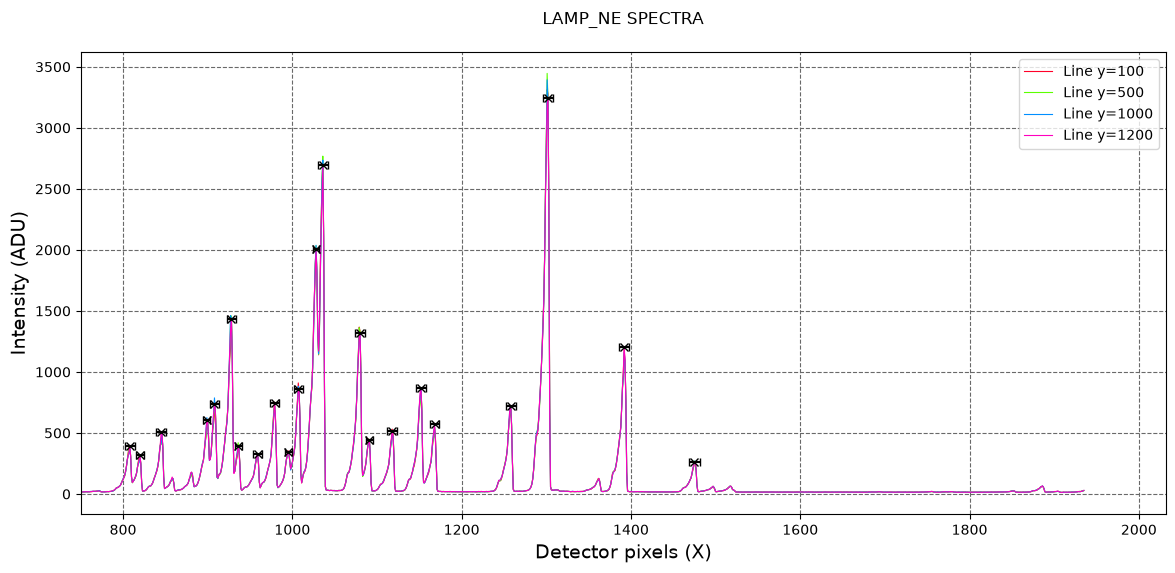

In [18]:
from scipy.signal import find_peaks
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(14,6))

lines = [100,500,1000,1200] # spectral y-lines selection for plot
n_lines = len(lines)
colors = cm.gist_rainbow(np.linspace(0, 1, n_lines))

for i, l in enumerate(lines):
    data = MASTER_SCIENCE_UNCORR[i,:][::-1]
    x, y = np.arange(1936), data

    peaks, prop = find_peaks(y, height=200, distance=7, prominence=5,width=2)#,threshold=100)

    ax.plot(x,(y),c=colors[i],lw=0.8,label=f'Line y={lines[i]}')#,marker='.')

ax.errorbar(x=peaks, y=(y[peaks]), xerr=prop['widths'],color='black',marker='x',ls='', capsize=3)

# for p in peaks:
#     ax.axvline(x=p)

ax.grid(ls='--',c='dimgrey')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
ax.set_title(f'{OBJECT_NAME} SPECTRA\n')
# ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)
# ax.set_xlim(760,790)
# ax.set_xlim(150,250) # 
# ax.set_xlim(620,670)
# ax.set_xlim(50,120)
# ax.set_ylim(0,450)
ax.set_xlim(750,)
ax.legend()
plt.show()


## **7. Peak finding and asymetric gaussian fitting**
---

In [19]:
from collections import defaultdict
from scipy.optimize import curve_fit
from scipy.special import erfcx

# Function used for LSF fitting
def emg_left(x, A, mu, sigma, tau, c):
    sigma = np.abs(sigma)
    tau = np.abs(tau)
    u = (sigma**2 + tau*(x - mu)) / (sigma*tau*np.sqrt(2))
    return c + (A/(2*tau)) * np.exp(-(x-mu)**2/(2*sigma**2)) * erfcx(u)

def fwhm_numeric(func, popt, x_center, search_range=30, n_points=5000):
    """Calcule le FWHM numériquement à partir de la fonction fittée (EMG ou autre)."""
    A, mu, sigma, tau, c = popt
    x_fine = np.linspace(x_center - search_range, x_center + search_range, n_points)
    y_fine = func(x_fine, *popt)

    y_peak = y_fine.max() - c          # amplitude au-dessus du fond
    half_max = c + y_peak / 2

    above = y_fine >= half_max
    if not above.any():
        return np.nan

    idx = np.where(above)[0]
    x_left = x_fine[idx[0]]
    x_right = x_fine[idx[-1]]
    return x_right - x_left

# Fit peak function
def fit_peak(x, y, x0, amp_guess, all_peak_positions, left_win_max=16, right_win_max=4):
    others = [p for p in all_peak_positions if p != x0] # we look for all the other peak around the current one
    left_neighbors = [p for p in others if p < x0] # list of left peaks
    right_neighbors = [p for p in others if p > x0] # list of right peaks

    # window determinatnion to avoid overstepping on other peak
    left_win = min(left_win_max, (x0 - max(left_neighbors)) / 2) if left_neighbors else left_win_max
    right_win = min(right_win_max, (min(right_neighbors) - x0) / 2) if right_neighbors else right_win_max
    left_win = max(left_win, 3) 
    right_win = max(right_win, 3)

    mask = (x > x0 - left_win) & (x < x0 + right_win)
    xf, yf = x[mask], y[mask]

    # look at a small portion on the far left of the peak, and calculate the median to estimate the noise continum
    far_left_mask = (x > x0 - left_win) & (x < x0 - left_win + 5)
    baseline_guess = np.median(y[far_left_mask]) if far_left_mask.sum() > 0 else np.percentile(yf, 5)

    p0 = [amp_guess * 3, x0, 2.0, 5.0, baseline_guess]
    bounds = (
        [0,             x0 - left_win/2,  0.3, 0.2, 0],
        [amp_guess*20,  x0 + right_win/2, 15,  30,  baseline_guess*2 + 10]
    )

    try:
        popt, pcov = curve_fit(emg_left, xf, yf, p0=p0, bounds=bounds, maxfev=30000)
        if not np.all(np.isfinite(popt)) or not np.all(np.isfinite(pcov)):
            return None, None, xf, yf, np.nan
        fwhm = fwhm_numeric(emg_left, popt, x_center=popt[1], search_range=max(left_win, right_win)*1.5)
        return popt, pcov, xf, yf, fwhm
    except (RuntimeError, ValueError, TypeError):
        return None, None, xf, yf, np.nan



tracks = defaultdict(list) # we use a dictionnary instead of a dataframe for dynamic append
next_id = 0
last_row_peaks = {}
tol = 1.5

x_complet = np.arange(MAX_W)
n_rows = MAX_H
rows = np.arange(0, n_rows, 10)  # sample every 10 rows, changeable


for row in tqdm(rows):
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
    peaks, prop = find_peaks(y_row, height=200, prominence=7, distance=5, width=2) # reuse the previous parameters estimated in previous cell
    peak_positions = x_complet[peaks]

    current_row_peaks = {}

    for pk in peaks:
        p_entier = int(x_complet[pk])

        popt, pcov, xf, yf, fwhm = fit_peak(
            x_complet, y_row, x_complet[pk], y_row[pk], peak_positions
        )

        ### Peak match tracking 
        matched_id = None
        for x_prev, tid in last_row_peaks.items(): # comparaison with each peak from the previsou row
            if abs(p_entier - x_prev) < tol: # if a peak from the previous line has less than the pixel tolerance allowed
                matched_id = tid # if match, we assign this peak as belonging to the same emission line
                break
        if matched_id is None:
            matched_id = next_id # if not, we assign it a new id
            next_id += 1

        if popt is None: # if no fit if found, we assign a failed match tag to the peak
            tracks[matched_id].append({
                'row': row,
                'peak_pixel_raw': p_entier,
                'fit_success': False,
            })
            current_row_peaks[p_entier] = matched_id
            continue

        A, mu, sigma, tau, c = popt
        perr = np.sqrt(np.diag(pcov))
        A_err, mu_err, sigma_err, tau_err, c_err = perr

        # Il reconstruit le profil ajusté à haute résolution (xx avec 1000 points) pour trouver le vrai sommet du pic au sous-pixel près (vrai_sommet_x, vrai_sommet_y), ce qui est crucial en spectroscopie de haute précision pour s'affranchir de la discrétisation des pixels.
        #Toutes ces métriques physiques sont stockées dans le dictionnaire tracks.
        xx = np.linspace(xf.min(), xf.max(), 1000)
        yy_fit = emg_left(xx, *popt)
        idx_max = np.argmax(yy_fit)
        vrai_sommet_x = xx[idx_max]
        vrai_sommet_y = yy_fit[idx_max]

        tracks[matched_id].append({
            'row': row,
            'peak_pixel_raw': p_entier,
            'fit_success': True,
            'mu': mu,
            'mu_err': mu_err,
            'A': A,
            'A_err': A_err,
            'sigma': sigma,
            'sigma_err': sigma_err,
            'tau': tau,
            'tau_err': tau_err,
            'c': c,
            'c_err': c_err,
            'sommet_x': vrai_sommet_x,
            'sommet_y': vrai_sommet_y,
            'fwhm': fwhm,
        })

        current_row_peaks[p_entier] = matched_id

    last_row_peaks = current_row_peaks

 11%|█▏        | 14/122 [00:01<00:08, 13.05it/s]/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_71401/49943632.py:10: RuntimeWarning: invalid value encountered in multiply
  return c + (A/(2*tau)) * np.exp(-(x-mu)**2/(2*sigma**2)) * erfcx(u)
100%|██████████| 122/122 [00:10<00:00, 12.19it/s]


### **Conversion of dictionnary to pandas DataFrame for easier use**
---

In [20]:
import pandas as pd

rows_list = []
for track_id, entries in tracks.items():
    for entry in entries:
        row_dict = {'track_id': track_id}
        row_dict.update(entry)
        rows_list.append(row_dict)

df_tracks = pd.DataFrame(rows_list)
df_tracks = df_tracks.sort_values(['track_id', 'row']).reset_index(drop=True)

## **8. Emission line plot and sorting/filter for calibration**
---

### **8.a Choosing and plotting filtered emission line to validate for fitting**

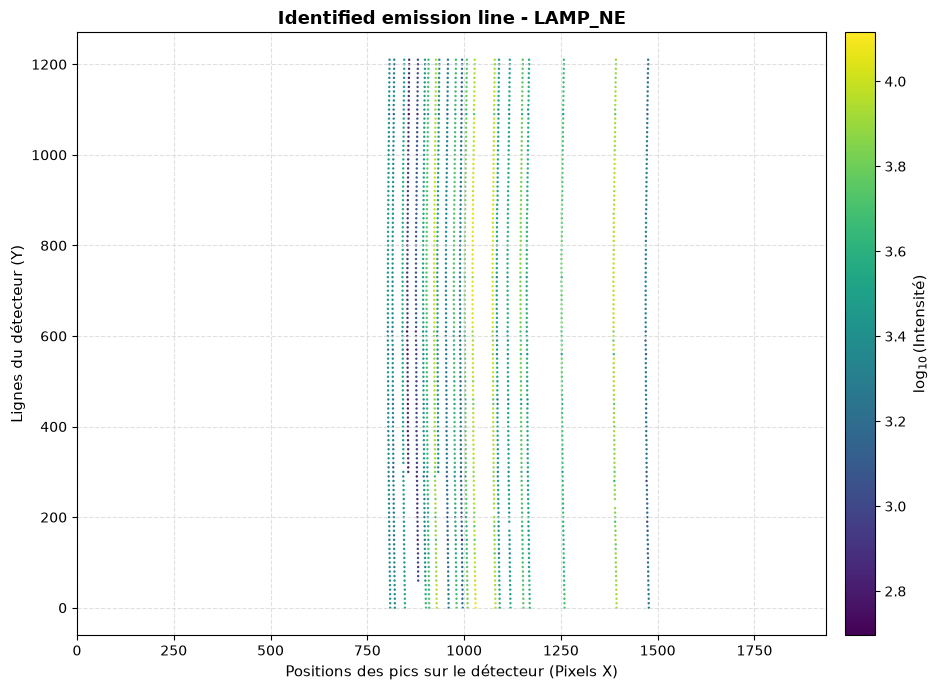

In [21]:
MIN_POINTS = 60  # chosen minimum amount of point to be considered a valid emission line

track_lengths = df_tracks.groupby('track_id')['row'].transform('count') # convert as count to see how many point are associated to emission line
df_plot = df_tracks[(track_lengths > MIN_POINTS) & df_tracks['fit_success']].copy() # we only keep emission line from valid fit and with enought point associated to said emission line

df_plot['A_clipped'] = df_plot['A'].clip(lower=1e-10)
df_plot['log_A'] = np.log10(df_plot['A_clipped'])

vmin, vmax = df_plot['log_A'].min(), df_plot['log_A'].max()

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df_plot['mu'],
    df_plot['row'],
    c=df_plot['log_A'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    s=12,
    marker='.',
    edgecolor='none',
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log_{10}(\mathrm{Intensité})$', fontsize=11)

ax.set_xlabel('Positions des pics sur le détecteur (Pixels X)', fontsize=11)
ax.set_ylabel('Lignes du détecteur (Y)', fontsize=11)
ax.set_title(f"Identified emission line - {OBJECT_NAME}", fontsize=13, weight='bold')
ax.grid(True, linestyle='--', color='lightgrey', alpha=0.7)
ax.set_xlim(0, MAX_W)

plt.tight_layout()
plt.show()

In [22]:
# Here, we can choose to only keep 'clean' emission line, based on the minimum amount of point associated to said line (MIN_POINTS)
track_lengths = df_tracks.groupby('track_id')['row'].count()
valid_ids = track_lengths[track_lengths >= MIN_POINTS].index  # seuil à ajuster
df_tracks_clean = df_tracks[df_tracks['track_id'].isin(valid_ids)].reset_index(drop=True)
# df_tracks_clean.info()

In [23]:
# Visualisation of left valid emission line in dataframe
valid_ids = df_tracks_clean['track_id'].unique()
print(valid_ids)

[ 0  1  2  3  4  5  7  8  9 10 11 13 14 15 16 17 18 20 21 22 28 29]


In [28]:
def pipeline_calibration_geometrique(
    df_tracks, n_sigma=1.5, iters=3, min_points=50, sigma_inst=0.1
):
    """Calcule le fit parabolique de chaque trace en éliminant le bruit et les
    sauts de raie par sigma-clipping itératif, puis calcule le Chi2 réduit.

    Attend un DataFrame avec au minimum les colonnes :
    'track_id', 'row', 'mu', 'A', 'sigma', 'c', 'fit_success'

            tracks[matched_id].append({
            'row': row,
            'peak_pixel_raw': p_entier,
            'fit_success': True,
            'mu': mu,
            'mu_err': mu_err,
            'A': A,
            'A_err': A_err,
            'sigma': sigma,
            'sigma_err': sigma_err,
            'tau': tau,
            'tau_err': tau_err,
            'c': c,
            'c_err': c_err,
            'sommet_x': vrai_sommet_x,
            'sommet_y': vrai_sommet_y,
        })
    """
    fits = {}

    for track_id, group in df_tracks.groupby('track_id'):
        # On ne garde que les lignes où le fit EMG a réussi
        group = group[group['fit_success']]

        if len(group) < min_points:
            continue

        rows_t = group['row'].to_numpy()
        x_t = group['sommet_x'].to_numpy()
        insty = group['A'].to_numpy()
        std = group['sigma'].to_numpy()
        noise = group['c'].to_numpy()
        mu_err = group['mu_err'].to_numpy()
        fwhm = group['fwhm'].to_numpy()
        
        # ! Emission filtering from line intensity ######
        seuil_intensite = np.median(insty) * 0.5  # remove too faint emission line, might not be useful, need to see later
        mask_lumineux = insty > seuil_intensite
        # ! #####

        rows_clean = rows_t[mask_lumineux]
        x_clean = x_t[mask_lumineux]
        insty_clean = insty[mask_lumineux]
        std_clean = std[mask_lumineux]
        noise_clean = noise[mask_lumineux]
        mu_err_clean = mu_err[mask_lumineux]
        fwhm_clean = fwhm[mask_lumineux]

       

        # BOUCLE DE SIGMA-CLIPPING ITERATIF
        for i in range(iters):
            if len(x_clean) < min_points:
                break  # trop purgé

            coeffs_temp = np.polyfit(rows_clean, x_clean, deg=2)
            x_mod_temp = np.polyval(coeffs_temp, rows_clean)

            residus = x_clean - x_mod_temp
            std_residus = np.std(residus)

            if std_residus < 1e-5:
                break

            mask = np.abs(residus) < (n_sigma * std_residus) # mask meaning we only consider value whose std are below a certain n-sigma (std) value
            # that way, we can remove big outlier from fit to ensure accuracy

            rows_clean = rows_clean[mask]
            x_clean = x_clean[mask]
            insty_clean = insty_clean[mask]
            std_clean = std_clean[mask]
            noise_clean = noise_clean[mask]
            mu_err_clean = mu_err_clean[mask]
            fwhm_clean = fwhm_clean[mask]

        

        # FIT FINAL ET CALCUL DU CHI2 NORMALISÉ
        if len(x_clean) >= 20: 
            mu_err_clean = np.clip(mu_err_clean, a_min=0.01, a_max=2.0)
            poids = 1.0 / mu_err_clean
            
            # Le fit pondéré
            res_final = np.polyfit(rows_clean, x_clean, deg=2, full=True, w=poids)

            coeffs_finals = res_final[0]
            ssr_array = res_final[1]

            dof = len(x_clean) - 3

            if len(ssr_array) > 0 and dof > 0:
                ssr = ssr_array[0]
                # CORRECTION : ssr contient déjà les poids (1/mu_err)^2. 
                # On divise simplement par les degrés de liberté (dof).
                chi2_norm = ssr / dof 
            else:
                chi2_norm = np.nan


            fits[track_id] = (
                coeffs_finals,
                rows_clean,
                x_clean,
                insty_clean,
                chi2_norm,
                std_clean,
                noise_clean,
                fwhm_clean,
            )

    return fits

In [29]:

def plot_track_and_residuals(fits_dict, track_id):
    # 1. Vérifier si l'identifiant existe
    if track_id not in fits_dict:
        print(f"Le track_id {track_id} n'est pas dans le dictionnaire 'fits'.")
        return

    # Extraire les données stockées
    coeffs, rows_t, x_t, insty, chi2_norm, std, noise, fwhm = fits_dict[track_id]

    # --- CORRECTION 1 : Une vraie grille continue pour le tracé de la ligne ---
    # Au lieu d'utiliser len(x_t), on crée 1000 points parfaits de 0 à 1200 (la hauteur du CCD)
    rows_virtuelles = np.linspace(np.min(rows_t), np.max(rows_t), 1000)
    x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

    # --- CORRECTION 2 : Calcul des résidus EXACTEMENT sur les vrais points ---
    # Pour calculer le résidu d'un point réel, il faut évaluer la parabole sur sa vraie ligne !
    x_fit_points_reels = np.polyval(coeffs, rows_t)
    residuals = x_t - x_fit_points_reels

    sns.set_theme(style="whitegrid")
    fig, (ax_main, ax_res) = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Affichage des points de données (avec le trou, c'est normal !)
    sns.scatterplot(
        x=rows_t,
        y=x_t,
        hue=insty,  # Optionnel : réactivé pour voir l'intensité en couleur !
        palette="viridis",
        ax=ax_main,
        alpha=0.8,
        edgecolor=None,
    )

    ax_main.errorbar(
        x=rows_t,
        y=x_t,
        yerr=1/3*std,  # Remplace par ton tableau 'std' si tu as une erreur par point
        fmt="none",  # CRUCIAL : dit à Matplotlib de ne pas dessiner de points
        ecolor="gray",  # Une couleur sobre (ex: gris) pour ne pas polluer ta palette viridis
        elinewidth=0.8,  # Épaisseur fine pour que ce soit élégant
        capsize=1.5,  # Largeur des petits ergots horizontaux au bout des barres
        alpha=0.4,  # Légère transparence pour ne pas surcharger visuellement si tu as beaucoup de points
    )

    # --- CORRECTION 3 : On trace la ligne rouge avec les variables virtuelles ---
    sns.lineplot(
        x=rows_virtuelles,  # On utilise la grille sans trou
        y=x_fit_virtuel,  # Et le fit sans trou
        color="red",
        linewidth=2.5,
        ax=ax_main,
        label=f"Fit Deg 2 (ID: {track_id}) - Chi2 {chi2_norm:.2f}",
    )

    ax_main.set_ylabel("Position X")
    ax_main.set_title(
        f"Ajustement Parabolique et Résidus pour la Trace n°{track_id}",
        fontsize=14,
    )
    ax_main.legend()

    # --- GRAPHIQUE DES RÉSIDUS ---
    sns.scatterplot(
        x=rows_t,
        y=residuals,
        color="purple",
        alpha=0.6,
        ax=ax_res,
        edgecolor=None,
    )
    # Ligne horizontale à 0 (le fit parfait)
    ax_res.axhline(y=0, color="black", linestyle="--", linewidth=1.5)

    ax_res.set_xlabel("Lignes (Rows)")
    ax_res.set_ylabel("Résidus (Data - Fit)")
    

    plt.tight_layout()
    plt.show()

Available ids = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 28, 29]


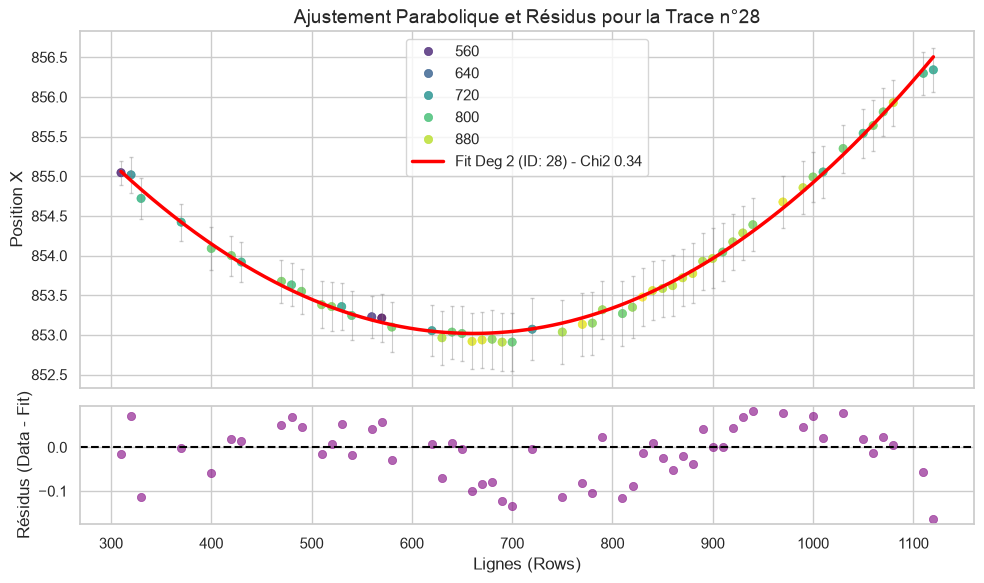

In [30]:
# amplitude_mask = df_tracks['sommet_y'] > 2000
# df_ampMask = df_tracks[amplitude_mask]

fits = pipeline_calibration_geometrique(
    df_tracks, n_sigma=1.5, iters=3, min_points=60, sigma_inst=0.15
    # sigma_inst is the estimated instrumental error in pixels
)

available_ids = list(fits.keys())
print(f'Available ids = {available_ids}')

if available_ids:
    target_id = available_ids[20]
    plot_track_and_residuals(fits, target_id)

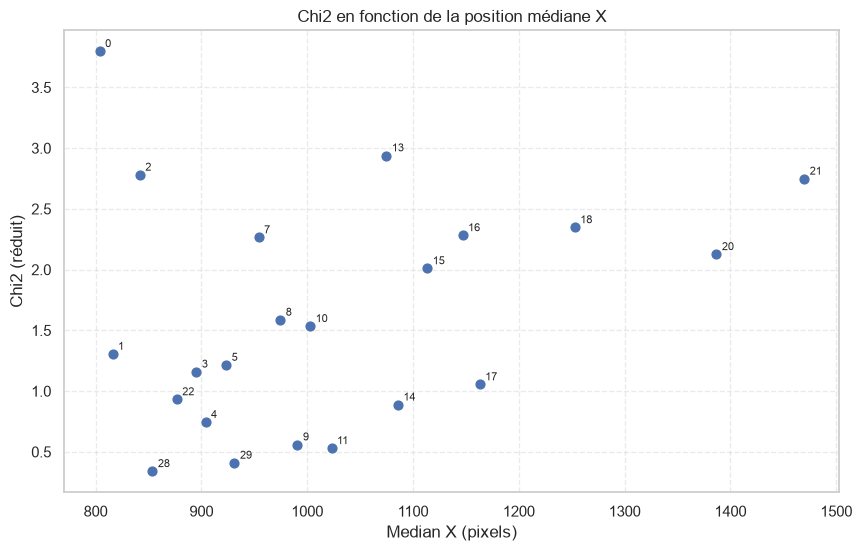

In [31]:
chi2_pos_array = np.zeros((len(available_ids), 2), dtype=float)

for i, tid in enumerate(available_ids):
    chi2 = fits[tid][4]
    median_x = np.median(fits[tid][2])
    chi2_pos_array[i, :] = [chi2, median_x]



x = chi2_pos_array[:, 1]
y = chi2_pos_array[:, 0]

plt.figure(figsize=(10,6))
plt.scatter(x, y, c='C0', s=40)
for i, tid in enumerate(available_ids):
    plt.annotate(str(tid), (x[i], y[i]), xytext=(4,3), textcoords='offset points', fontsize=8)
plt.xlabel('Median X (pixels)')
plt.ylabel('Chi2 (réduit)')
plt.title('Chi2 en fonction de la position médiane X')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

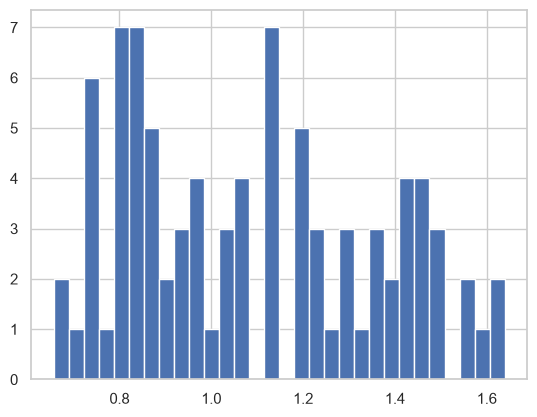

In [ ]:
# [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 28, 29]
plt.hist(fits[13][5], bins=30)
plt.show()

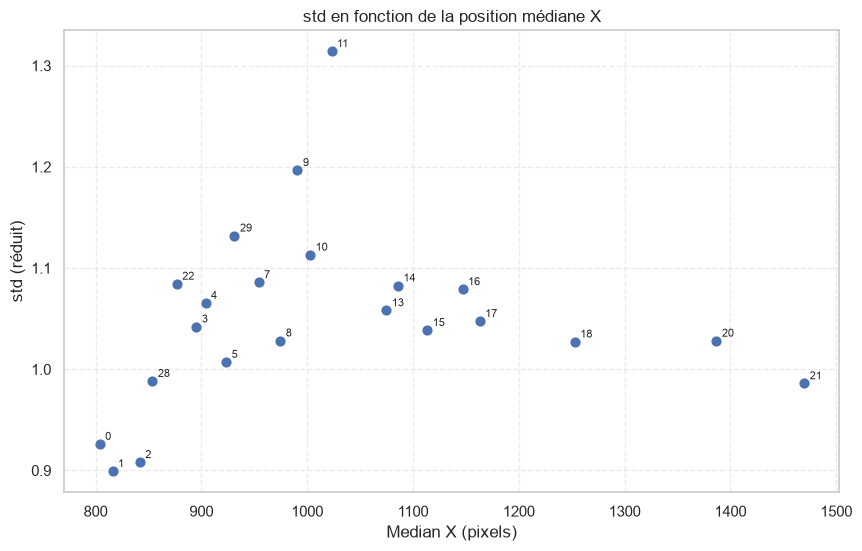

In [32]:
std_pos_array = np.zeros((len(available_ids), 2), dtype=float)
for i, tid in enumerate(available_ids):
    std = np.median(fits[tid][5])
    median_x = np.median(fits[tid][2])
    std_pos_array[i, :] = [std, median_x]

x = std_pos_array[:, 1]
y = std_pos_array[:, 0]

plt.figure(figsize=(10,6))
plt.scatter(x, y, c='C0', s=40)
for i, tid in enumerate(available_ids):
    plt.annotate(str(tid), (x[i], y[i]), xytext=(4,3), textcoords='offset points', fontsize=8)
plt.xlabel('Median X (pixels)')
plt.ylabel('std (réduit)')
plt.title('std en fonction de la position médiane X')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<>:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_71266/217210701.py:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('Largeur du pic $\sigma$ (pixels)')
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_71266/217210701.py:20: SyntaxWarning: "\s" is a

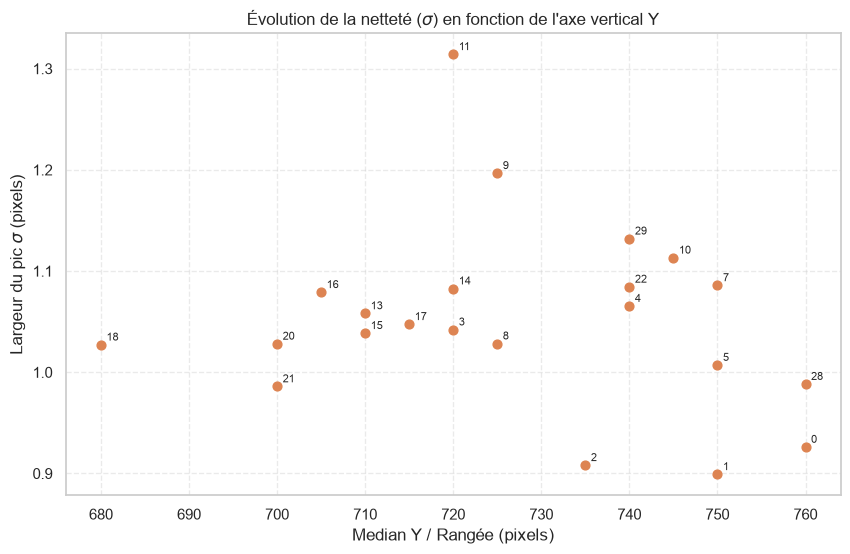

In [ ]:
# Tableau pour stocker [std, median_row]
std_pos_y_array = np.zeros((len(available_ids), 2), dtype=float)

for i, tid in enumerate(available_ids):
    std = np.median(fits[tid][5])          # fits[tid][5] = std_clean
    median_y = np.median(fits[tid][1])      # fits[tid][1] = rows_clean (l'axe Y du CCD)
    std_pos_y_array[i, :] = [std, median_y]

y_ccd = std_pos_y_array[:, 1]
sigma_pic = std_pos_y_array[:, 0]

plt.figure(figsize=(10,6))
plt.scatter(y_ccd, sigma_pic, c='C1', s=40)  # Couleur orange pour changer

for i, tid in enumerate(available_ids):
    plt.annotate(str(tid), (y_ccd[i], sigma_pic[i]), xytext=(4,3), textcoords='offset points', fontsize=8)

plt.xlabel('Median Y / Rangée (pixels)')
plt.ylabel('Largeur du pic $\sigma$ (pixels)')
plt.title('Évolution de la netteté ($\sigma$) en fonction de l\'axe vertical Y')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_71266/3578624462.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.colorbar(sc, label='Largeur du pic $\sigma$ (pixels)')


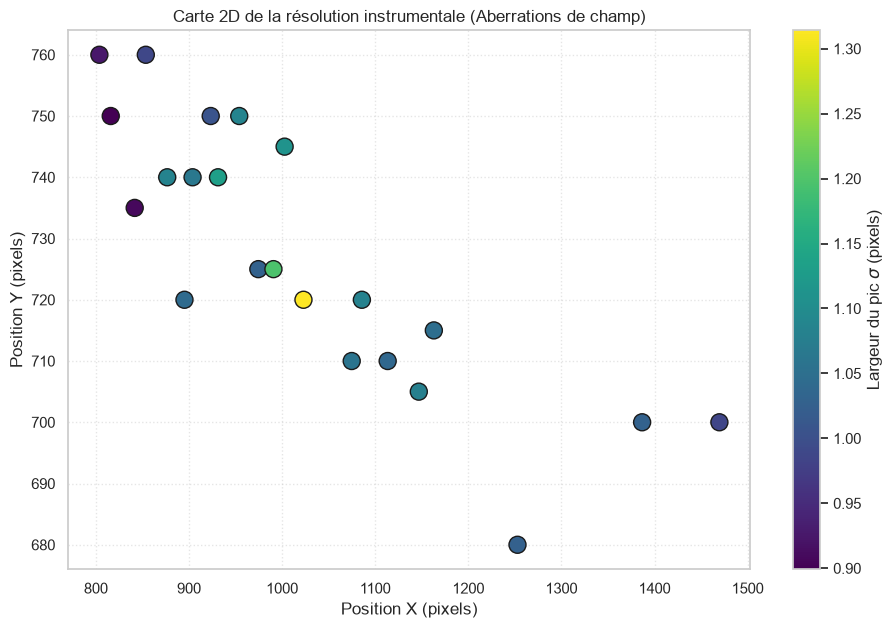

In [ ]:
x_médian = std_pos_array[:, 1]    # Ton X précédent
y_médian = std_pos_y_array[:, 1]  # Ton Y actuel
valeur_sigma = std_pos_array[:, 0]

plt.figure(figsize=(11, 7))
sc = plt.scatter(x_médian, y_médian, c=valeur_sigma, cmap='viridis', s=150, edgecolor='k')
plt.colorbar(sc, label='Largeur du pic $\sigma$ (pixels)')

plt.xlabel('Position X (pixels)')
plt.ylabel('Position Y (pixels)')
plt.title('Carte 2D de la résolution instrumentale (Aberrations de champ)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:32: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:44: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:32: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:44: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_71401/1414912558.

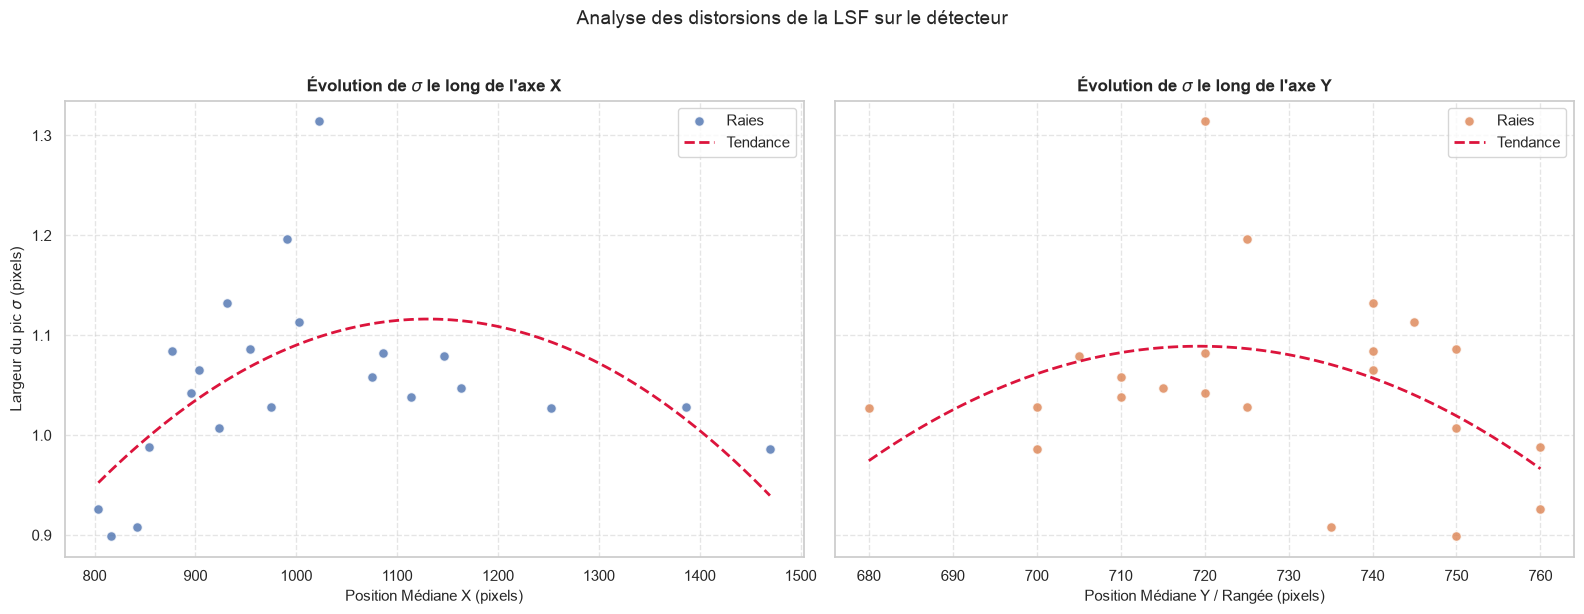

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraction des données sur les deux axes
available_ids = list(fits.keys())
data_list = []

for tid in available_ids:
    std = np.median(fits[tid][5])       # Largeur moyenne de la raie
    median_x = np.median(fits[tid][2])  # Position horizontale x_clean
    median_y = np.median(fits[tid][1])  # Position verticale rows_clean
    data_list.append([std, median_x, median_y])

# Conversion en array pour manipuler facilement les colonnes
data_arr = np.array(data_list)
sigma_vals = data_arr[:, 0]
x_vals = data_arr[:, 1]
y_vals = data_arr[:, 2]

# 2. Création des graphiques de tendance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- TENDANCE AXE X ---
ax1.scatter(x_vals, sigma_vals, c='C0', s=50, edgecolor='w', alpha=0.8, label='Raies')
# Optionnel : Ajoute une ligne de tendance polynomiale pour mieux voir la courbe
poly_x = np.polyfit(x_vals, sigma_vals, 2)
x_trend = np.linspace(x_vals.min(), x_vals.max(), 100)
ax1.plot(x_trend, np.polyval(poly_x, x_trend), color='crimson', linestyle='--', lw=2, label='Tendance')

ax1.set_xlabel('Position Médiane X (pixels)', fontsize=11)
ax1.set_ylabel('Largeur du pic $\sigma$ (pixels)', fontsize=11)
ax1.set_title('Évolution de $\sigma$ le long de l\'axe X', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- TENDANCE AXE Y ---
ax2.scatter(y_vals, sigma_vals, c='C1', s=50, edgecolor='w', alpha=0.8, label='Raies')
# Optionnel : Ligne de tendance pour l'axe Y
poly_y = np.polyfit(y_vals, sigma_vals, 2)
y_trend = np.linspace(y_vals.min(), y_vals.max(), 100)
ax2.plot(y_trend, np.polyval(poly_y, y_trend), color='crimson', linestyle='--', lw=2, label='Tendance')

ax2.set_xlabel('Position Médiane Y / Rangée (pixels)', fontsize=11)
ax2.set_title('Évolution de $\sigma$ le long de l\'axe Y', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.suptitle('Analyse des distorsions de la LSF sur le détecteur', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

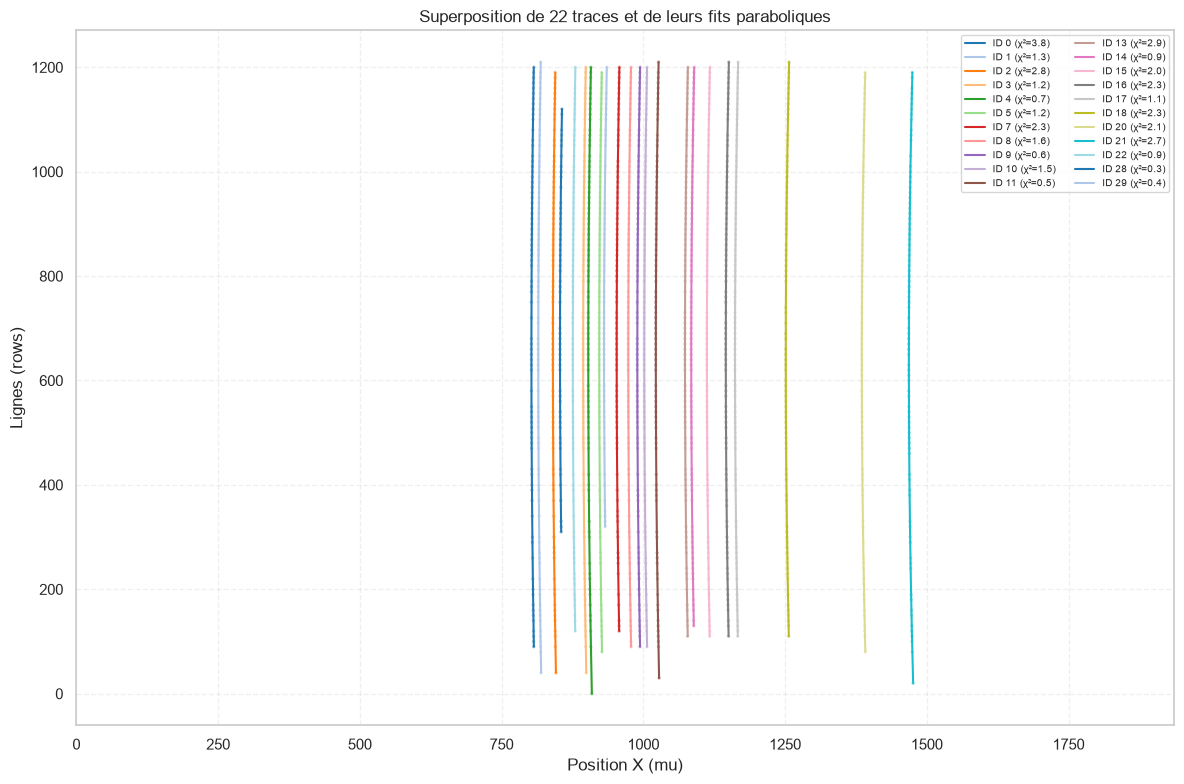

In [34]:
def plot_all_tracks_and_fits(fits_dict, alpha_points=0.4, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.get_cmap('tab20')  # 20 couleurs distinctes, se répète après
    n = len(fits_dict)

    for i, (track_id, data) in enumerate(fits_dict.items()):
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
        color = cmap(i % 20)

        # points de données
        ax.scatter(x_clean,
            rows_clean,
            s=6, alpha=alpha_points, color=color, edgecolor='none'
        )

        # fit parabolique (grille continue pour une ligne lisse)
        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

        ax.plot(x_fit_virtuel,
            rows_virtuelles,
            color=color, linewidth=1.5,
            label=f'ID {track_id} (χ²={chi2_norm:.1f})'
        )

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title(f'Superposition de {n} traces et de leurs fits paraboliques')
    ax.grid(True, linestyle='--', alpha=0.3)

    # légende : peut vite devenir énorme si beaucoup de tracks, donc on la limite
    if n <= 25:
        ax.legend(fontsize=7, ncol=2, loc='best')
    ax.set_xlim(0,MAX_W)
    plt.tight_layout()
    plt.show()


# utilisation
plot_all_tracks_and_fits(fits)

In [ ]:
# %matplotlib qt
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(10,8))
plt.imshow(np.flip(MASTER_SCIENCE_UNCORR[:,:]),norm=LogNorm())
plt.xlim(655,MAX_W)
plt.colorbar()
plt.grid(False)

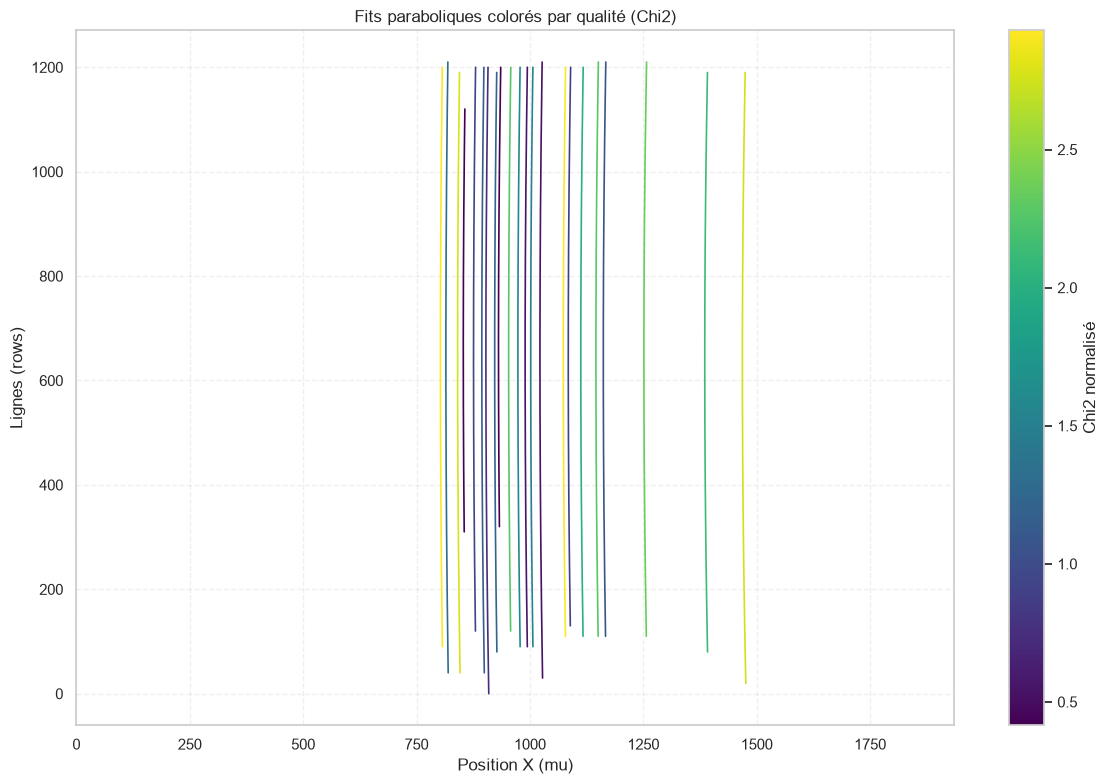

In [35]:
def plot_all_tracks_and_fits_by_chi2(fits_dict, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    chi2_values = [d[4] for d in fits_dict.values() if np.isfinite(d[4])]
    vmin, vmax = np.percentile(chi2_values, [5, 95])  # évite les outliers extrêmes

    cmap = plt.get_cmap('viridis')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
        norm_val = np.clip((chi2_norm - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

        ax.plot(x_fit_virtuel,rows_virtuelles,  color=color, linewidth=1.2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Chi2 normalisé')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title('Fits paraboliques colorés par qualité (Chi2)')
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    ax.set_xlim(0,MAX_W)
    plt.show()

plot_all_tracks_and_fits_by_chi2(fits)

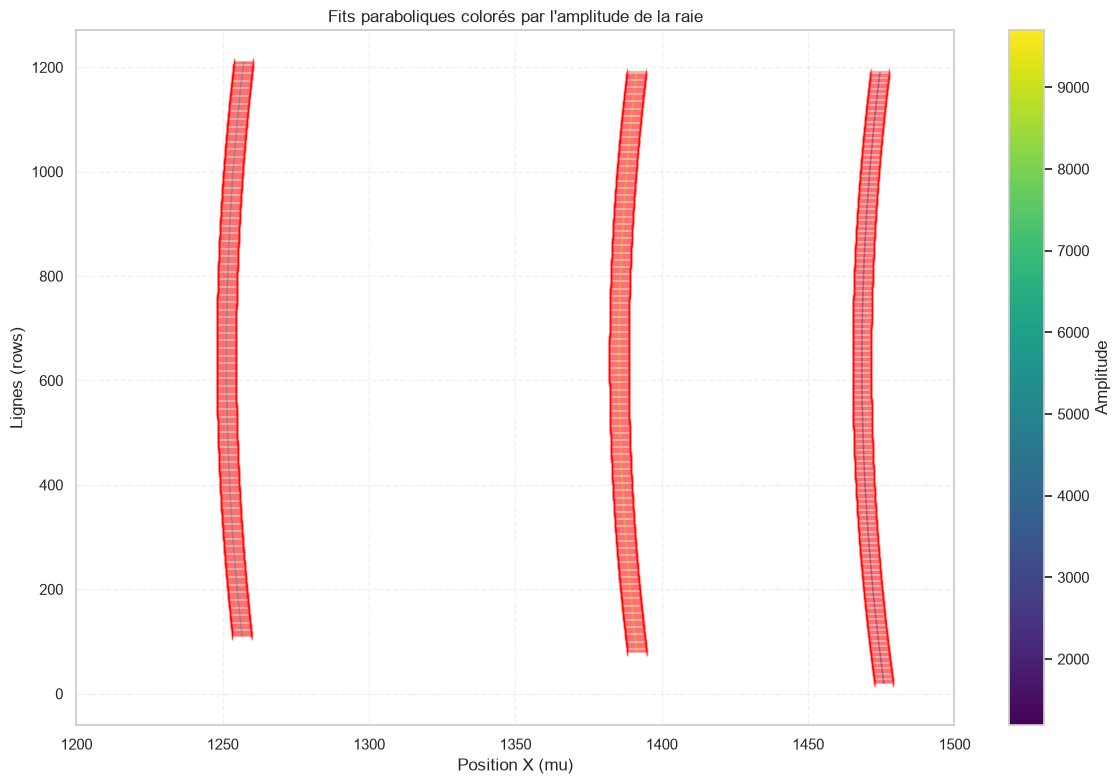

In [66]:
def plot_all_tracks_and_fits_by_amplitude(fits_dict, figsize=(12, 8), log_scale=True):
    fig, ax = plt.subplots(figsize=figsize)

    # amplitude représentative de chaque track (médiane sur tous ses points)
    amp_values = [np.median(d[3]) for d in fits_dict.values() if np.all(np.isfinite(d[3]))]

    if log_scale:
        amp_values = np.log10(np.clip(amp_values, 1e-10, None))

    vmin, vmax = np.percentile(amp_values, [5, 95])  # évite les outliers extrêmes
    cmap = plt.get_cmap('viridis')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data

        amp_med = np.median(insty_clean)
        if log_scale:
            amp_med = np.log10(max(amp_med, 1e-10))

        norm_val = np.clip((amp_med - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)
        fwhm = np.nanmedian(fwhm)

        err = ax.errorbar(
            x=x_fit_virtuel,
            y=rows_virtuelles,
            xerr=fwhm,
            color=color,
            linewidth=1.2,
            capsize=3,
            ecolor='red',
            alpha=0.4
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'$\log_{10}$(Amplitude)' if log_scale else 'Amplitude')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title("Fits paraboliques colorés par l'amplitude de la raie")
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.set_xlim(0, 300)
    # ax.set_xlim(300, 600)
    # ax.set_xlim(800, 915)
    ax.set_xlim(915, 1050)
    ax.set_xlim(1050, 1200)
    ax.set_xlim(1200, 1500)
    plt.tight_layout()
    plt.show()


plot_all_tracks_and_fits_by_amplitude(fits,log_scale=False)

In [ ]:
# %matplotlib qt

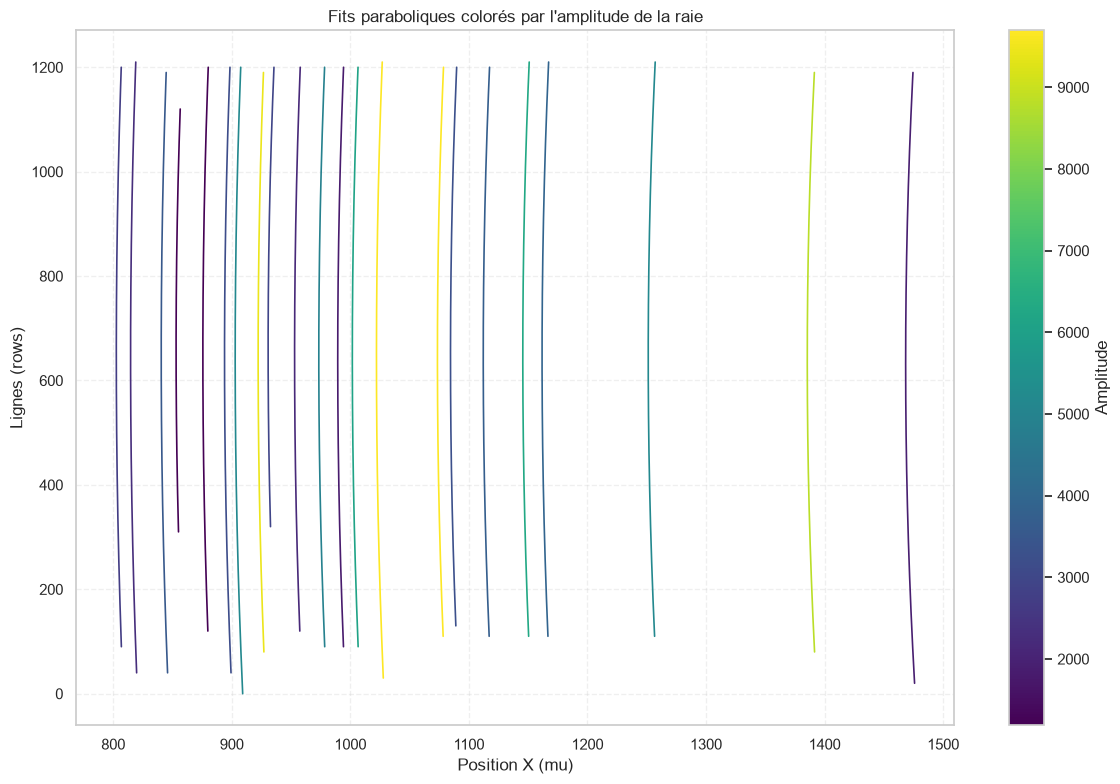

In [36]:
def plot_all_tracks_and_fits_by_amplitude(fits_dict, figsize=(12, 8), log_scale=True):
    fig, ax = plt.subplots(figsize=figsize)

    # amplitude représentative de chaque track (médiane sur tous ses points)
    amp_values = [np.median(d[3]) for d in fits_dict.values() if np.all(np.isfinite(d[3]))]

    if log_scale:
        amp_values = np.log10(np.clip(amp_values, 1e-10, None))

    vmin, vmax = np.percentile(amp_values, [5, 95])  # évite les outliers extrêmes
    cmap = plt.get_cmap('viridis')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data

        amp_med = np.median(insty_clean)
        if log_scale:
            amp_med = np.log10(max(amp_med, 1e-10))

        norm_val = np.clip((amp_med - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

        ax.plot(x_fit_virtuel, rows_virtuelles, color=color, linewidth=1.2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'$\log_{10}$(Amplitude)' if log_scale else 'Amplitude')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title("Fits paraboliques colorés par l'amplitude de la raie")
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.set_xlim(1200, MAX_W)
    plt.tight_layout()
    plt.show()


plot_all_tracks_and_fits_by_amplitude(fits,log_scale=False)

585.24, 588.18, 594.48, 597.54, 602.98, 607.42, 609.6, 614.32, 616.34, 621.72, 626.64, 630.46, 633.44, 640.22, 
650.64, 653.28, 659.88, 667.82, 671.7, 
692.94
724.46
743.88

In [37]:
longueurs_onde_triees = [585.24, 
                         588.18, 
                         594.48, 
                         597.54, 
                         602.98, 
                         607.42, 
                         609.60, 
                         614.32, 
                         616.34, 
                         621.72, 
                         626.64, 
                         630.46, 
                         633.44, 
                         640.22, 
                         650.64, 
                         653.28, 
                         659.88, 
                         667.82, 
                         671.70, 
                         692.94,
                         724.46,
                         743.88]

### 1. Tri des tracks par position et association aux longueurs d'onde connues

In [38]:
import numpy as np

# Tri des tracks par position moyenne en X (du plus à gauche au plus à droite)
fits_sorted = dict(sorted(fits.items(), key=lambda item: np.median(item[1][2])))

print(f"{len(fits_sorted)} raies triées : {list(fits_sorted.keys())}")

# --- Catalogue des longueurs d'onde connues (à adapter selon ta lampe) ---
# ATTENTION : l'ordre doit correspondre à l'ordre spatial des raies (gauche -> droite)


# Sécurité : vérifier que le nombre de raies identifiées correspond au catalogue
assert len(fits_sorted) == len(longueurs_onde_triees), (
    f"Mismatch: {len(fits_sorted)} tracks détectées vs "
    f"{len(longueurs_onde_triees)} longueurs d'onde fournies"
)

raies_physiques = {
    tid: wl for tid, wl in zip(fits_sorted.keys(), longueurs_onde_triees)
}

22 raies triées : [0, 1, 2, 28, 22, 3, 4, 5, 29, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20, 21]


### 2. Calibration géométrique 2D (une loi de dispersion par ligne Y)

In [39]:
degre_calib = 3  # degré du polynôme Pixel X -> Lambda

valid_tids = list(fits_sorted.keys())
true_wavelengths = np.array([raies_physiques[tid] for tid in valid_tids])

calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))

for row in range(int(MAX_H) + 1):
    # position X théorique de chaque raie à cette ligne (via son fit parabolique)
    x_at_row = np.array([
        np.polyval(fits_sorted[tid][0], row) for tid in valid_tids
    ])

    # Lambda = f(X) pour cette ligne précise
    coeffs_calib = np.polyfit(x_at_row, true_wavelengths, deg=degre_calib)
    calib_matrix[row, :] = coeffs_calib

print("Calibration 2D terminée avec succès ! 🎉")

Calibration 2D terminée avec succès ! 🎉


### 3. Carte 2D de longueur d'onde

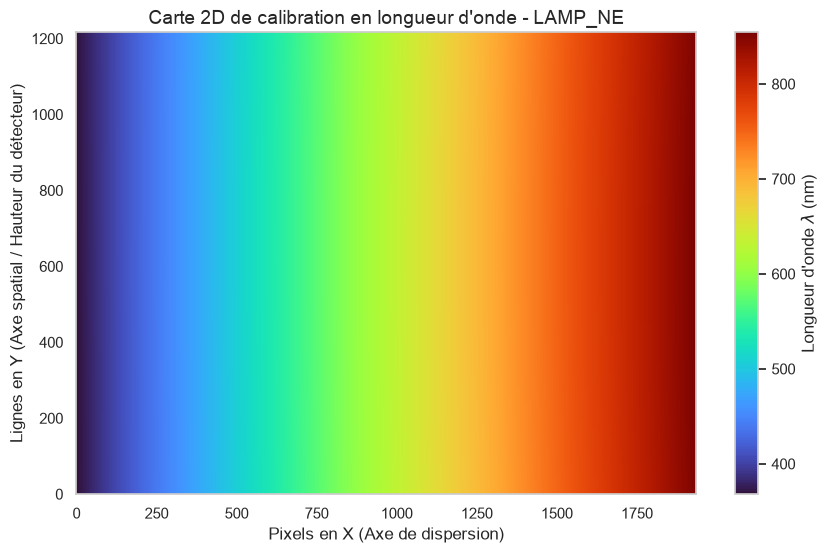

In [40]:
import matplotlib.pyplot as plt

x_pixels = np.arange(0, MAX_W)
wavelength_map_2D = np.zeros((int(MAX_H) + 1, MAX_W))

for row in range(int(MAX_H) + 1):
    wavelength_map_2D[row, :] = np.polyval(calib_matrix[row], x_pixels)

plt.figure(figsize=(10, 6))
plt.grid(False)
img = plt.imshow(wavelength_map_2D, aspect='auto', cmap='turbo', origin='lower')
cbar = plt.colorbar(img)
cbar.set_label(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.xlabel("Pixels en X (Axe de dispersion)", fontsize=12)
plt.ylabel("Lignes en Y (Axe spatial / Hauteur du détecteur)", fontsize=12)
plt.title(f"Carte 2D de calibration en longueur d'onde - {OBJECT_NAME}", fontsize=14)
# plt.xlim(200, 600)
plt.show()

### 4. Inspection du fit + résidus sur une ligne donnée

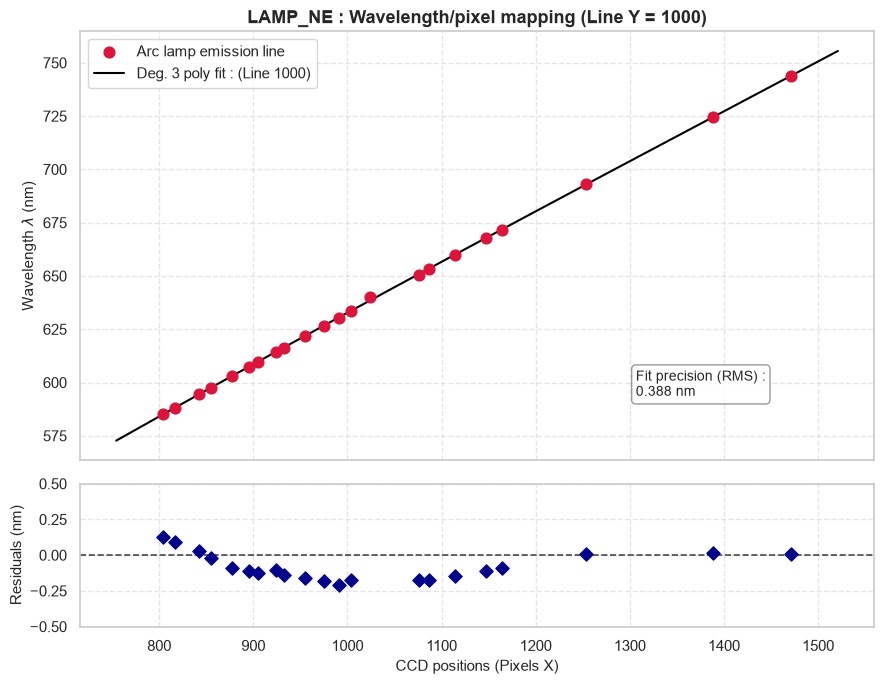

In [76]:
def plot_calib_ligne(ligne_choisie, fits_sorted, calib_matrix, true_wavelengths, degre_calib):
    valid_tids = list(fits_sorted.keys())
    x_mesure = np.array([
        np.polyval(fits_sorted[tid][0], ligne_choisie) for tid in valid_tids
    ])

    coeffs_calib_ligne = calib_matrix[ligne_choisie]
    x_fit_continu = np.linspace(x_mesure.min() - 50, x_mesure.max() + 50, 1000)
    wl_fit_continu = np.polyval(coeffs_calib_ligne, x_fit_continu)

    wl_predit = np.polyval(coeffs_calib_ligne, x_mesure)
    residus = true_wavelengths - wl_predit
    rms = np.sqrt(np.mean(residus**2))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    ax1.scatter(x_mesure, true_wavelengths, color='crimson', marker='o', s=60,
                label='Arc lamp emission line', zorder=3)
    ax1.plot(x_fit_continu, wl_fit_continu, color='black', lw=1.5,
             label=f'Deg. {degre_calib} poly fit : (Line {ligne_choisie})')
    ax1.set_ylabel(r"Wavelength $\lambda$ (nm)", fontsize=11)
    ax1.set_title(f"{OBJECT_NAME} : Wavelength/pixel mapping (Line Y = {ligne_choisie})",
                  fontsize=13, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')

    text_perf = f"Fit precision (RMS) :\n{rms:.3f} nm"
    ax1.text(0.70, 0.15, text_perf, transform=ax1.transAxes, fontsize=10,
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    ax2.scatter(x_mesure, residus, color='darkblue', marker='D', s=45, zorder=3)
    ax2.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
    ax2.set_xlabel("CCD positions (Pixels X)", fontsize=11)
    ax2.set_ylabel("Residuals (nm)", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_ylim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()


plot_calib_ligne(1000, fits_sorted, calib_matrix, true_wavelengths, degre_calib)

### 5. Continuité des coefficients de calibration le long du CCD

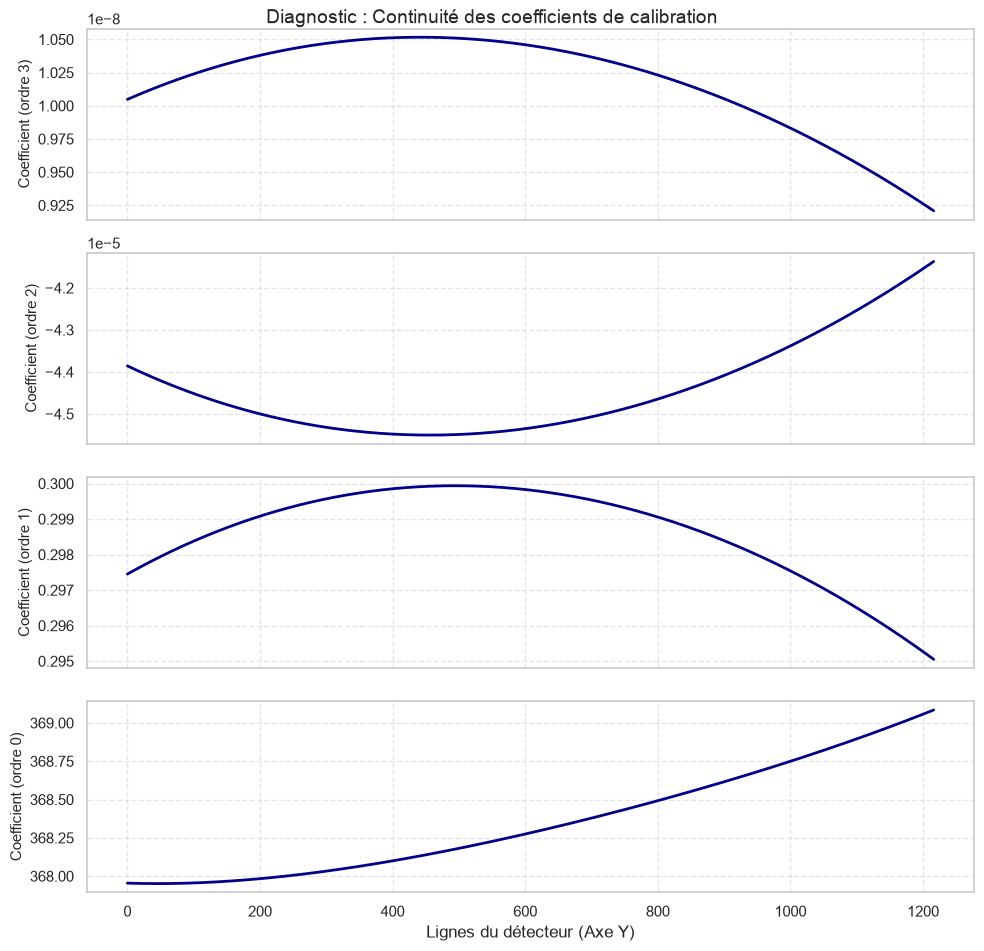

In [42]:
fig, axes = plt.subplots(degre_calib + 1, 1, figsize=(10, 2.5 * (degre_calib + 1)), sharex=True)
lignes_Y = np.arange(0, int(MAX_H) + 1)
noms_coefs = [f"Coefficient (ordre {degre_calib - i})" for i in range(degre_calib + 1)]

for i in range(degre_calib + 1):
    axes[i].plot(lignes_Y, calib_matrix[:, i], color='darkblue', lw=2)
    axes[i].set_ylabel(noms_coefs[i], fontsize=11)
    axes[i].grid(ls='--', alpha=0.5)

axes[-1].set_xlabel("Lignes du détecteur (Axe Y)", fontsize=12)
fig.suptitle("Diagnostic : Continuité des coefficients de calibration", fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

### 6. Comparaison de la loi de dispersion à plusieurs hauteurs

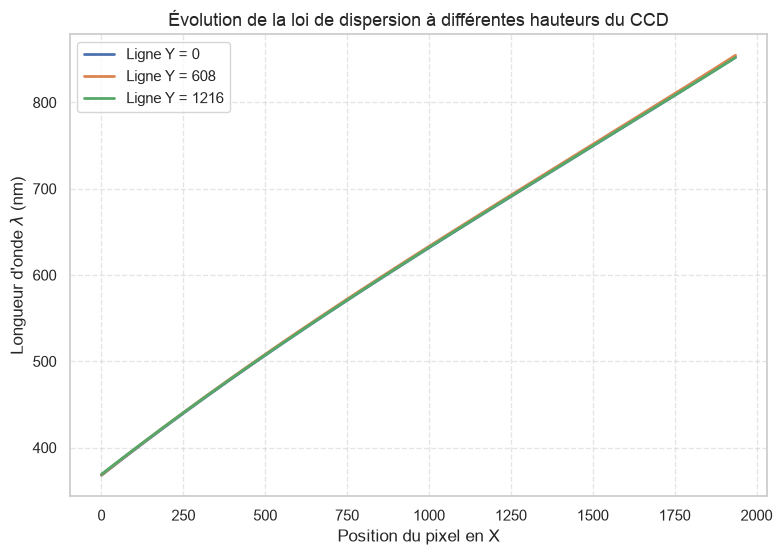

In [43]:
rows_to_check = [0, int(MAX_H) // 2, int(MAX_H)]
x_fine = np.linspace(0, MAX_W, 500)

plt.figure(figsize=(9, 6))
for r in rows_to_check:
    wl_fine = np.polyval(calib_matrix[r], x_fine)
    plt.plot(x_fine, wl_fine, lw=2, label=f"Ligne Y = {r}")

plt.xlabel("Position du pixel en X", fontsize=12)
plt.ylabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.title("Évolution de la loi de dispersion à différentes hauteurs du CCD", fontsize=13)
plt.legend()
plt.grid(ls='--', alpha=0.5)
plt.show()

### 7. Spectre scientifique calibré

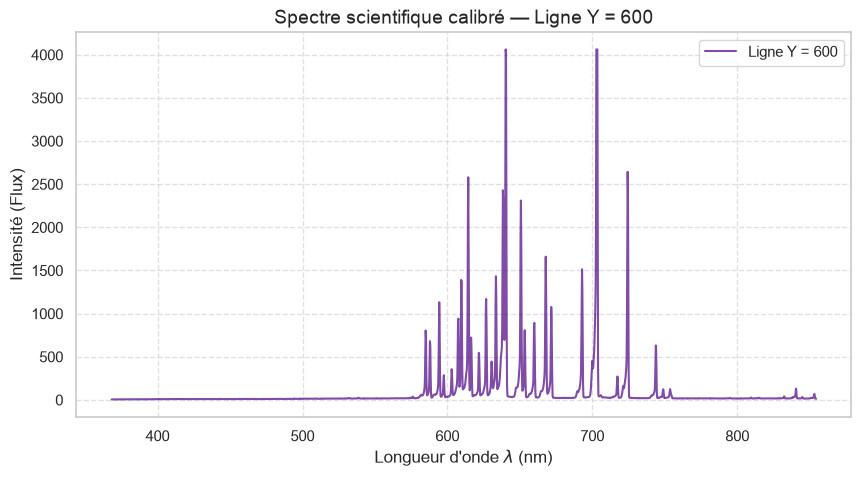

In [44]:
y_choisi = 600
flux_ligne = MASTER_SCIENCE_UNCORR[y_choisi, :][::-1]
lambdas_ligne = np.polyval(calib_matrix[y_choisi], np.arange(MAX_W))  # <- la vraie carte calibrée

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(lambdas_ligne, flux_ligne, color='indigo', lw=1.5, alpha=0.7,
         label=f'Ligne Y = {y_choisi}')
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Spectre scientifique calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# # sauvegarde de la courbe de longueur d'onde pour la ligne choisie en FITS
# from astropy.io import fits # Redéfinit 'fits' comme étant le module
# data = (lambdas_ligne)
# filename = f"{OBJECT_NAME}_lambda_ligne_{y_choisi}.fits"
# hdu = fits.PrimaryHDU(data.astype(np.float32))
# hdu.header['YLINE'] = (int(y_choisi), 'Detector line used to compute this array')
# hdu.header['BUNIT'] = ('nm', 'Wavelength unit')
# hdu.header['COMMENT'] = "Wavelength solution for one CCD row"
# hdu.writeto(filename, overwrite=True)

# print(f"Saved: {filename}")

### 8. Zoom sur une zone spectrale

In [49]:
LAMBDA_MIN, LAMBDA_MAX = 550, 800
masque_zone = (lambdas_ligne >= LAMBDA_MIN) & (lambdas_ligne <= LAMBDA_MAX)

plt.figure(figsize=(12, 5), dpi=100)
plt.plot(lambdas_ligne[masque_zone], flux_ligne[masque_zone],
         color='crimson', lw=1, label=f'Zone {LAMBDA_MIN}-{LAMBDA_MAX} nm',marker='.',ms='3')
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Zoom sur le spectre calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.axvline(435.82)
# plt.axvline(435.6)

plt.legend()
plt.show()

In [45]:
# import numpy as np

# def leave_one_out_check(fits_sorted, longueurs_onde_triees, row, degre_calib):
#     valid_tids = list(fits_sorted.keys())
#     true_wl = np.array(longueurs_onde_triees)
#     x_pos = np.array([np.polyval(fits_sorted[tid][0], row) for tid in valid_tids])

#     residus_loo = []
#     for i in range(len(valid_tids)):
#         # on enlève la raie i
#         x_train = np.delete(x_pos, i)
#         wl_train = np.delete(true_wl, i)

#         coeffs_loo = np.polyfit(x_train, wl_train, deg=degre_calib)
#         wl_predite = np.polyval(coeffs_loo, x_pos[i])
#         residus_loo.append(wl_predite - true_wl[i])

#     return np.array(residus_loo), valid_tids

# residus_loo, tids = leave_one_out_check(fits_sorted, longueurs_onde_triees, row=400, degre_calib=3)

# for tid, r, wl in zip(tids, residus_loo, longueurs_onde_triees):
#     print(f"Raie {wl:8.3f} nm  (tid={tid}) : écart LOO = {r:+.3f} nm")

# print(f"\nRMS leave-one-out : {np.sqrt(np.mean(residus_loo**2)):.3f} nm")

### Visualisation FWHM sur le détecteur

In [46]:
def fit_fwhm_trend(rows_clean, fwhm_clean, deg=1):
    """Ajuste une tendance FWHM(row) lissée, robuste au bruit résiduel."""
    coeffs_fwhm = np.polyfit(rows_clean, fwhm_clean, deg=deg)
    return coeffs_fwhm

def eval_fwhm_trend(coeffs_fwhm, rows):
    return np.polyval(coeffs_fwhm, rows)

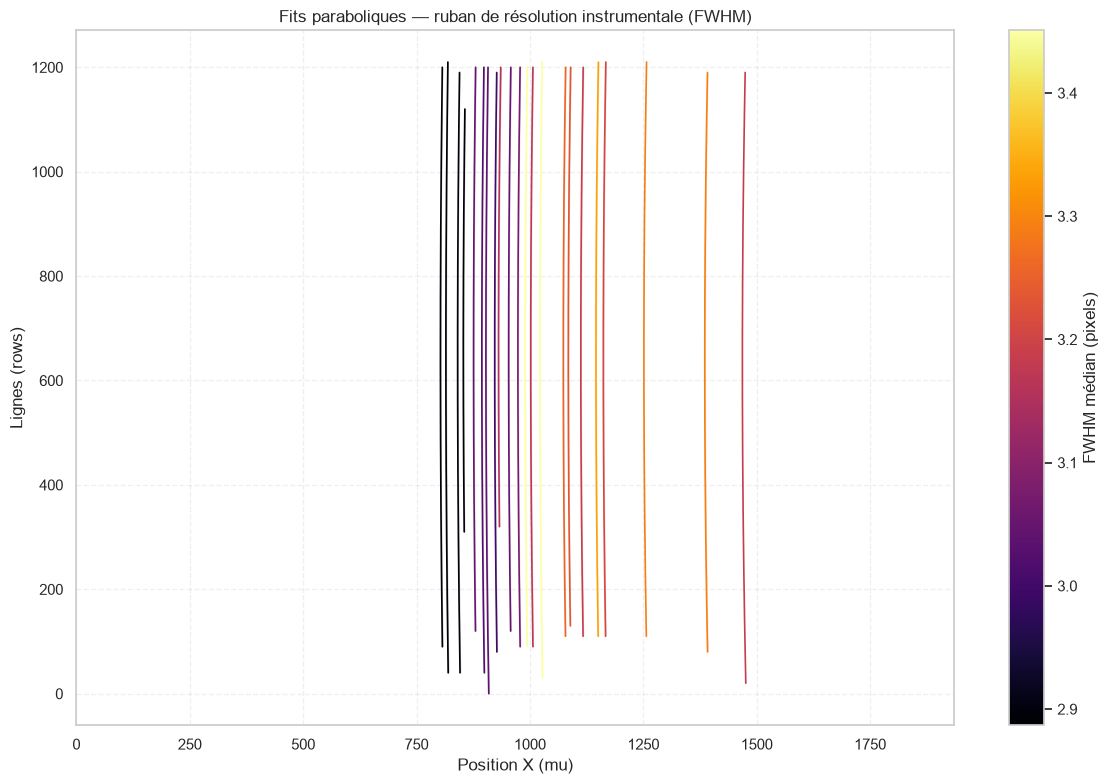

In [47]:
def plot_all_tracks_and_fits_by_fwhm(fits_dict, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    fwhm_medians = [np.nanmedian(d[7]) for d in fits_dict.values() if np.all(np.isfinite(d[7]))]
    vmin, vmax = np.nanpercentile(fwhm_medians, [5, 95])
    cmap = plt.get_cmap('inferno')

    for track_id, data in fits_dict.items():
        coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data

        if len(rows_clean) < 10 or not np.any(np.isfinite(fwhm_clean)):
            continue

        # tendance FWHM lissée le long de la raie (pas un scalaire unique)
        coeffs_fwhm = fit_fwhm_trend(rows_clean, fwhm_clean, deg=1)

        rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 300)
        x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)
        fwhm_fit = eval_fwhm_trend(coeffs_fwhm, rows_virtuelles)

        fwhm_med = np.nanmedian(fwhm_clean)
        norm_val = np.clip((fwhm_med - vmin) / (vmax - vmin), 0, 1)
        color = cmap(norm_val)

        # trace centrale
        ax.plot(x_fit_virtuel, rows_virtuelles, color=color, linewidth=1.2)

        # ruban de largeur = FWHM local (demi-largeur de chaque côté)
        ax.fill_betweenx(
            rows_virtuelles,
            x_fit_virtuel - fwhm_fit / 2,
            x_fit_virtuel + fwhm_fit / 2,
            color=color, alpha=0.25, linewidth=0
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('FWHM médian (pixels)')

    ax.set_ylabel('Lignes (rows)')
    ax.set_xlabel('Position X (mu)')
    ax.set_title("Fits paraboliques — ruban de résolution instrumentale (FWHM)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0, MAX_W)
    plt.tight_layout()
    plt.show()


plot_all_tracks_and_fits_by_fwhm(fits)

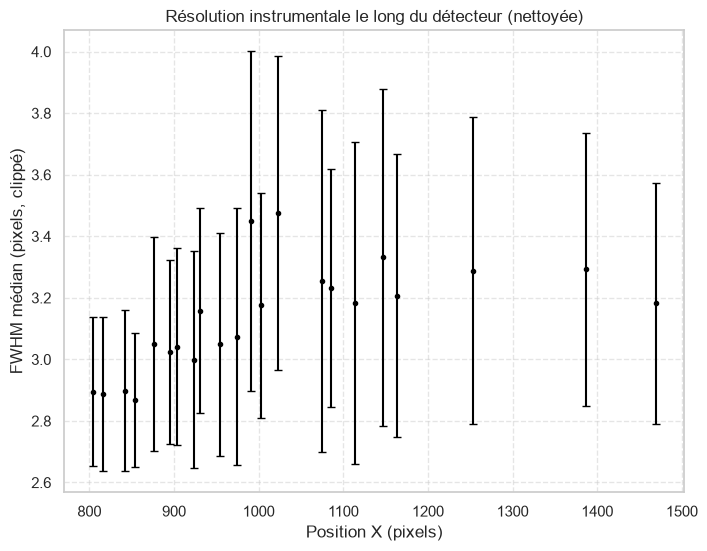

Detector median over x-axis [800-1500]: (3.167±0.184) px


In [74]:
FWHM_med, FWHM_mad, FWHM_pos, FWHM_id = [], [], [], []

for tid, data in fits.items():
    coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data
    if not np.any(np.isfinite(fwhm_clean)):
        continue
    med = np.nanmedian(fwhm_clean)
    mad = np.nanmedian(np.abs(fwhm_clean - med)) * 1.4826  # équivalent robuste de l'écart-type
    FWHM_med.append(med)
    FWHM_mad.append(mad)
    FWHM_pos.append(np.median(x_clean))
    FWHM_id.append(tid)

fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(x=FWHM_pos, y=FWHM_med, yerr=FWHM_mad, ls='', marker='.', capsize=3, color='black')
ax.set_ylabel('FWHM médian (pixels, clippé)')
ax.set_xlabel('Position X (pixels)')
ax.set_title("Résolution instrumentale le long du détecteur (nettoyée)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(f'Detector median over x-axis [800-1500]: ({np.median(FWHM_med):.3f}±{np.nanmedian(np.abs(FWHM_med - np.median(FWHM_med))) * 1.4826:.3f}) px')

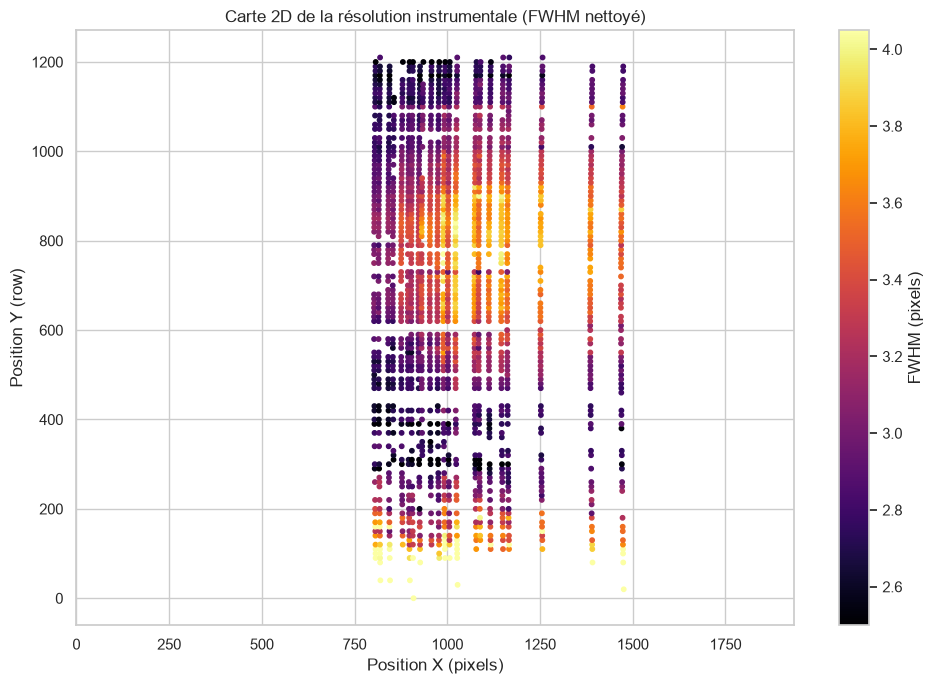

In [49]:
rows_all, x_all, fwhm_all, tid_all = [], [], [], []

for tid, data in fits.items():
    coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm_clean = data
    rows_all.extend(rows_clean)
    x_all.extend(x_clean)
    fwhm_all.extend(fwhm_clean)
    tid_all.extend([tid] * len(rows_clean))

rows_all = np.array(rows_all)
x_all = np.array(x_all)
fwhm_all = np.array(fwhm_all)

# sécurité : ignorer les NaN résiduels pour le calcul des bornes de couleur
valid = np.isfinite(fwhm_all)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    x_all[valid], rows_all[valid],
    c=fwhm_all[valid], cmap='inferno', s=10,
    vmin=np.nanpercentile(fwhm_all[valid], 2),
    vmax=np.nanpercentile(fwhm_all[valid], 98),
)
fig.colorbar(sc, label='FWHM (pixels)')
ax.set_xlabel('Position X (pixels)')
ax.set_ylabel('Position Y (row)')
ax.set_title('Carte 2D de la résolution instrumentale (FWHM nettoyé)')
ax.set_xlim(0, MAX_W)
plt.tight_layout()
plt.show()

---

### SNR Plot

-----

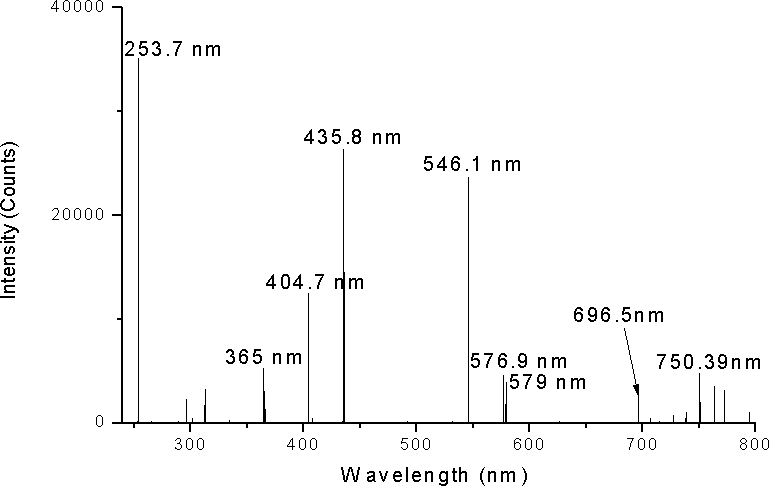

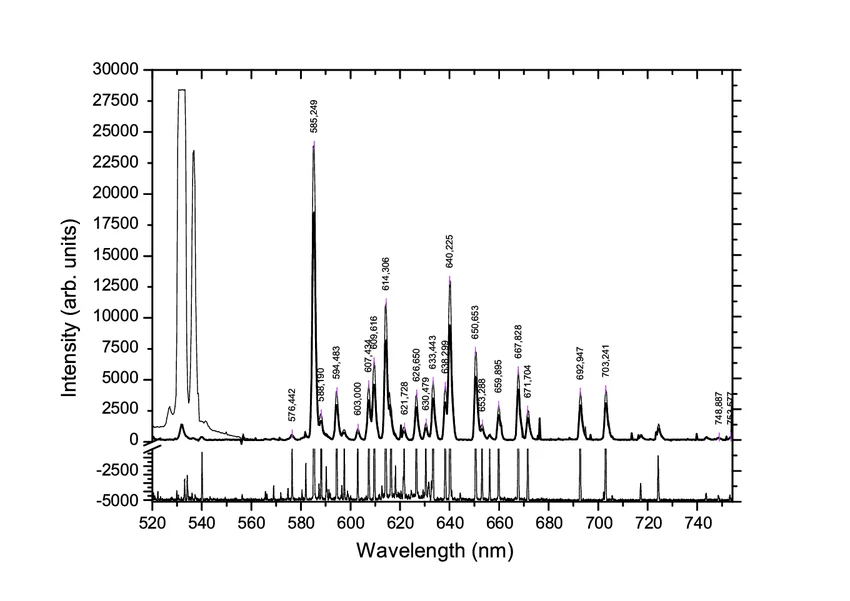

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red